In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
# Import libraries for data handling, visualization, scaling,
# KNN model, and evaluation

In [ ]:
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

df_train.info()
df_test.info()
# Loading training and testing datasets and display their information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [ ]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_train = df_train.drop(["Cabin"], axis=1)

df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test = df_test.drop(["Cabin"], axis=1)
# Filling missing Age values and remove the Cabin column

In [ ]:
df_train.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
# Convert columns to string, encode categorical data, combine datasets, and split into features and target
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)

df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [ ]:
df_train_num = df_train.select_dtypes(exclude="object")
df_train_obj = df_train.select_dtypes(include="object")

df_test_num = df_test.select_dtypes(exclude="object")
df_test_obj = df_test.select_dtypes(include="object")

In [ ]:
df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj = pd.get_dummies(df_test_obj, drop_first=True)

In [ ]:
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)

In [ ]:
X_train = Final_train_df.drop("Survived", axis=1)
y_train = Final_train_df["Survived"]

X_test = Final_test_df.drop("Survived", axis=1)
y_tes = Final_test_df["Survived"]

In [ ]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Age           0
SibSp         0
Parch         0
Fare          0
Survived_1    0
Pclass_2      0
Pclass_3      0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64
Age           0
SibSp         0
Parch         0
Fare          1
Survived_1    0
Pclass_2      0
Pclass_3      0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
X_test["Fare"] = X_test["Fare"].fillna(X_test["Fare"].median())

scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
Performance_Metric = []

for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)

    y_pred_k = knn_k.predict(scaled_X_test)

    accuracy_k = 1 - accuracy_score(y_tes, y_pred_k)
    Performance_Metric.append(accuracy_k)

Performance_Metric

[0.0071770334928229484,
 0.009569377990430672,
 0.009569377990430672,
 0.0071770334928229484,
 0.0071770334928229484,
 0.009569377990430672,
 0.009569377990430672,
 0.011961722488038284,
 0.014354066985645897,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.009569377990430672,
 0.009569377990430672,
 0.009569377990430672,
 0.009569377990430672,
 0.009569377990430672,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.011961722488038284,
 0.014354066985645897,
 0.014354066985645897,
 0.009569377990430672,
 0.011961722488038284,
 0.011961722488038284]

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(scaled_X_train, y_train)

y_pred = knn.predict(scaled_X_test)

accuracy_score(y_tes, y_pred)

0.992822966507177

Text(0.5, 1.0, 'Error Rate vs K Value')

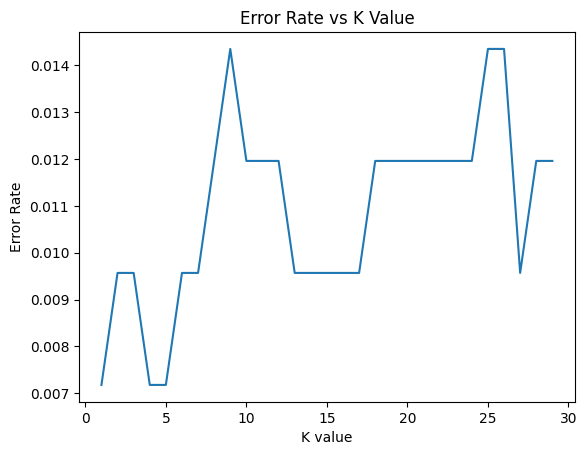

In [ ]:
plt.plot(range(1,30), Performance_Metric)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(scaled_X_train, y_train)

lr_pred = lr.predict(scaled_X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_tes, lr_pred))

Logistic Regression Accuracy: 1.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(scaled_X_train, y_train)

dt_pred = dt.predict(scaled_X_test)

print("Decision Tree Accuracy:", accuracy_score(y_tes, dt_pred))

Decision Tree Accuracy: 1.0


In [ ]:
print("KNN Accuracy:", accuracy_score(y_tes, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_tes, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_tes, dt_pred))

KNN Accuracy: 0.992822966507177
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


In [ ]:
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_tes, y_pred),
        accuracy_score(y_tes, lr_pred),
        accuracy_score(y_tes, dt_pred)
    ]
})

results

,Model,Accuracy
0,KNN,0.992823
1,Logistic Regression,1.000000
2,Decision Tree,1.000000


Comparing different machine learning algorithms is helpful in identifying the best model for a given dataset. In this study, Logistic Regression and Decision Tree were the best models, but all three models showed excellent predictive power for the Titanic survival dataset.